In [1]:
from lib import DoublePendulum, get_lyapunov, compute_points

In [2]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
import argparse
import numpy as np
import matplotlib.pyplot as plt

## Generate heatmap

In [3]:
res = 36
total = res**2

In [4]:
theta1_vals = np.linspace(0,360,res)
theta2_vals = theta1_vals.copy()

In [5]:
CHECKPOINTS = [5, 10]
epsilon = 1e-6
dt = 0.01

In [6]:
heats = {t: np.full((res, res), np.nan) for t in CHECKPOINTS}

In [7]:
with ProcessPoolExecutor(max_workers=20) as ex:
    futures = [ex.submit(compute_points, i, j, t1, t2, CHECKPOINTS, dt, epsilon)
               for i, t1 in enumerate(theta1_vals)
               for j, t2 in enumerate(theta2_vals)]
    
    done = 0
    for f in as_completed(futures):
        i, j, lyap_dict = f.result()
        for t, lyap in lyap_dict.items():
            heats[t][j, i] = lyap
        done += 1
        if done % max(1, total // 20) == 0:
            print(f"progress: {done}/{total} ({done/total*100:.1f}%)")

progress: 64/1296 (4.9%)
progress: 128/1296 (9.9%)
progress: 192/1296 (14.8%)
progress: 256/1296 (19.8%)
progress: 320/1296 (24.7%)
progress: 384/1296 (29.6%)
progress: 448/1296 (34.6%)
progress: 512/1296 (39.5%)
progress: 576/1296 (44.4%)
progress: 640/1296 (49.4%)
progress: 704/1296 (54.3%)
progress: 768/1296 (59.3%)
progress: 832/1296 (64.2%)
progress: 896/1296 (69.1%)
progress: 960/1296 (74.1%)
progress: 1024/1296 (79.0%)
progress: 1088/1296 (84.0%)
progress: 1152/1296 (88.9%)
progress: 1216/1296 (93.8%)
progress: 1280/1296 (98.8%)


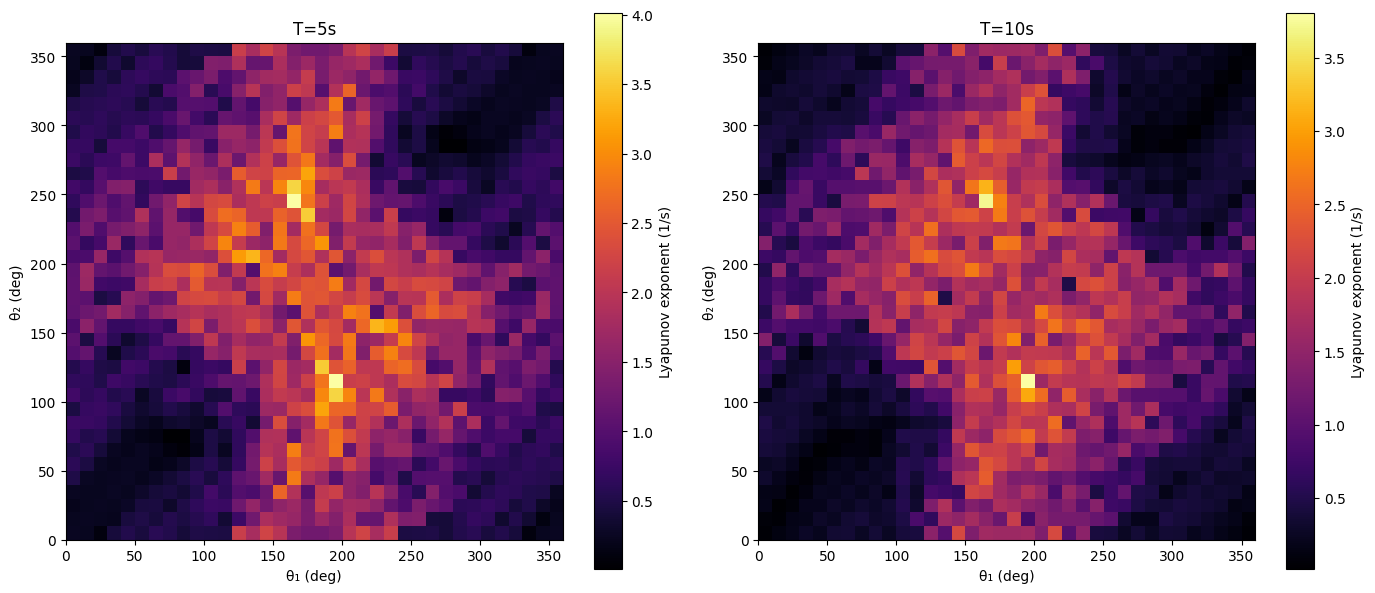

In [12]:
fig, axes = plt.subplots(1, len(CHECKPOINTS), figsize=(7 * len(CHECKPOINTS), 6))
for ax, t in zip(axes, CHECKPOINTS):
    im = ax.imshow(
        heats[t],
        extent=[0, 360, 0, 360],  # [left, right, bottom, top]
        origin='lower',
        cmap='inferno'
    )
    ax.set_title(f'T={t}s')
    ax.set_xlabel('θ₁ (deg)')
    ax.set_ylabel('θ₂ (deg)')
    fig.colorbar(im, ax=ax, label='Lyapunov exponent (1/s)')

fig.tight_layout()
plt.show()